# Projet d'Analyse Prédictive du Churn Client - Dataset Telco Customer Churn

## Contexte et Objectif

Ce notebook présente une analyse complète et approfondie du dataset **Telco Customer Churn**, un ensemble de données classique en science des données pour la prédiction de l'attrition client. L'objectif principal est de développer un modèle prédictif capable d'identifier les clients susceptibles de résilier leur abonnement auprès d'un opérateur télécom, permettant ainsi des actions préventives ciblées.

## Méthodologie Adoptée

L'approche suivie est structurée autour des bonnes pratiques de data science :

1. **Exploration des Données (EDA)** : Analyse univariée, bivariée et multivariée pour comprendre les patterns et relations dans les données
2. **Nettoyage et Préparation** : Traitement des valeurs manquantes, outliers, encodage des variables catégorielles
3. **Feature Engineering** : Création de nouvelles variables dérivées et transformations pour améliorer la performance prédictive
4. **Modélisation Stochastique** : Utilisation d'approches stochastiques pour l'optimisation des hyperparamètres et la sélection de modèles
5. **Évaluation et Comparaison** : Analyse comparative des performances avec métriques appropriées pour un problème de classification déséquilibré

## Technologies et Outils Utilisés

- **Langage** : Python 3.x
- **Bibliothèques principales** :
  - `pandas` et `numpy` : Manipulation et analyse des données
  - `matplotlib` et `seaborn` : Visualisation des données
  - `scikit-learn` : Algorithmes de machine learning et preprocessing
  - `xgboost`, `lightgbm` : Algorithmes de gradient boosting
  - `imbalanced-learn` : Gestion du déséquilibre des classes
- **Approches stochastiques** : RandomizedSearchCV pour l'optimisation des hyperparamètres

## Structure du Notebook

Le notebook est organisé de manière logique et pédagogique :

- **Section 1** : Importation des packages et configuration
- **Section 2** : Chargement et inspection générale du dataset
- **Section 3** : Analyse Exploratoire des Données (EDA) complète
- **Section 4** : Synthèse de l'EDA et insights clés
- **Section 5** : Feature Engineering et préparation des données
- **Section 6** : Modélisation avec approches stochastiques et évaluation comparative
- **Section 7** : Conclusion et perspectives

## 1. Importation des packages et libraries

Dans cette première section, nous importons toutes les bibliothèques nécessaires pour notre analyse. L'importation est organisée par catégories pour une meilleure lisibilité :

**Bibliothèques de base :**
- `numpy` : Calculs numériques et manipulation de tableaux
- `pandas` : Manipulation et analyse de données structurées
- `matplotlib.pyplot` : Création de graphiques statiques
- `seaborn` : Visualisation statistique avancée basée sur matplotlib
- `warnings` : Gestion des avertissements pour un output plus propre

**Bibliothèques de machine learning :**
- `sklearn` : Écosystème complet pour le ML (préprocessing, modèles, métriques)
- `xgboost` : Algorithme de gradient boosting optimisé
- `lightgbm` : Version légère et rapide de gradient boosting
- `imbalanced-learn` : Techniques spécialisées pour datasets déséquilibrés

**Utilitaires :**
- `os` : Interaction avec le système d'exploitation (création de dossiers)
- `math` : Fonctions mathématiques de base
- `joblib` : Sérialisation d'objets Python (pour sauvegarder les modèles)

Cette approche modulaire permet une maintenance facile et évite les imports inutiles.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import xgboost as xgb
import lightgbm as lgb
from sklearn import preprocessing
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import ExtraTreesClassifier, GradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV, cross_val_score, train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

import os
import math
import warnings
warnings.filterwarnings('ignore')

In [2]:
os.makedirs('./images', exist_ok=True)
os.makedirs('./models', exist_ok=True)

## 2. Chargement et inspection générale du dataset

Le dataset **Telco Customer Churn** est un ensemble de données synthétique créé par IBM pour illustrer les problématiques de churn dans l'industrie des télécommunications. Il contient des informations sur 7 043 clients d'un opérateur fictif, avec 21 variables décrivant leurs caractéristiques démographiques, leurs services souscrits et leur historique de paiement.

**Caractéristiques principales :**
- **Taille** : 7 043 observations, 21 variables
- **Période** : Données sur 4 mois d'activité client
- **Variable cible** : `Churn` (Yes/No) - Résiliation de l'abonnement
- **Type de variables** : Mix de numériques continues, discrètes et catégorielles

**Importance métier :**
Dans l'industrie des télécommunications, le churn représente un coût significatif. Acquérir un nouveau client coûte généralement 5 à 25 fois plus cher que de retenir un client existant. Une prédiction précise du churn permet :
- Des campagnes de rétention ciblées
- Des offres personnalisées pour les clients à risque
- Une optimisation des ressources marketing
- Une amélioration de la satisfaction client

**Variables clés à analyser :**
- **Démographiques** : âge, genre, situation familiale
- **Services** : type d'internet, téléphone, services additionnels
- **Contrat** : durée, type de paiement, facturation
- **Historique** : ancienneté, charges mensuelles/totales

In [3]:
telco_df = pd.read_csv("./Datasets/Telco-Customer-Churn.csv")

### 2.1 Apercu du dataset

In [4]:
# 5 first rows
telco_df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
# 5 last rows
telco_df.tail(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


### 2.2 Dimension et structure

In [6]:
# Shape of data
print(telco_df.shape)

(7043, 21)


In [7]:
# Columns of data
columns = telco_df.columns.tolist()
print(columns)

['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [8]:
# Info of datas
telco_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [9]:
# Types of data
telco_df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

### 2.3 Conclusion

In [10]:
print(f"Il y a {telco_df.shape[0]} échantillons.")
print(f"Il y a {telco_df.shape[1]} variables.")
print(f"Types des différentes colonnes : {telco_df.dtypes.astype(str).unique().tolist()}")
print(f"Colonnes inutiles : index, {telco_df.columns.tolist()[0]}")

Il y a 7043 échantillons.
Il y a 21 variables.
Types des différentes colonnes : ['object', 'int64', 'float64']
Colonnes inutiles : index, customerID


## 3. Analyse Exploratoire des données

### Objectifs de l'Analyse Exploratoire des Données (EDA)

L'Analyse Exploratoire des Données constitue la phase fondatrice de tout projet de data science. Elle vise à :

**Comprendre la structure des données :**
- Dimensions du dataset (nombre d'observations et de variables)
- Types de variables et leur distribution
- Présence de valeurs manquantes ou aberrantes

**Identifier les patterns et relations :**
- Distribution univariée de chaque variable
- Relations bivariées entre variables explicatives et cible
- Détection de corrélations et d'interactions

**Préparer le terrain pour la modélisation :**
- Validation des hypothèses sur les variables influentes
- Identification des variables à transformer ou créer
- Évaluation de la nécessité de techniques de preprocessing

**Aspects méthodologiques :**
- **Analyse univariée** : Statistiques descriptives, distributions, outliers
- **Analyse bivariée** : Corrélations, comparaisons par groupes
- **Analyse multivariée** : Interactions complexes et patterns globaux

**Métriques spécifiques au churn :**
- Taux de churn global et par segments
- Analyse des facteurs de risque
- Identification des profils clients à haut risque

Cette phase itérative permet de construire une compréhension profonde des données avant d'entamer les étapes de preprocessing et modélisation.

Les différentes colonnes du dataset sont :

+ Informations Démographiques
    - `gender` : Sexe du client (Masculin / Féminin).
    - `SeniorCitizen` : Indique si le client a plus de 65 ans (1 = Oui, 0 = Non).
    - `Partner` : Indique si le client vit en couple ou est marié (Yes / No).
    - `Dependents` : Indique si le client a des personnes à charge (Yes / No).

+ Informations du Compte Client
    - `tenure` : Ancienneté du client exprimée en mois.
    - `Contract` : Type d'engagement contractuel (Month-to-month, One year, Two year).
    - `PaymentMethod` : Méthode de paiement privilégiée (Electronic check, Mailed check, Bank transfer, Credit card).
    - `PaperlessBilling` : Souscription à la facturation dématérialisée (Yes / No).
    - `MonthlyCharges` : Montant mensuel facturé au client.
    - `TotalCharges` : Montant total cumulé généré depuis le début de l'abonnement.

+ Services Souscrits
    - `PhoneService` : Abonnement à une ligne téléphonique classique (Yes / No).
    - `MultipleLines` : Possession de plusieurs lignes téléphoniques actives (Yes / No / No phone service).
    - `InternetService` : Technologie d'accès internet (Fiber optic, DSL, No).
    - `OnlineSecurity` : Option de cybersécurité réseau incluse (Yes / No / No internet).
    - `OnlineBackup` : Espace de sauvegarde cloud alloué (Yes / No / No internet).
    - `DeviceProtection` : Assurance matérielle pour les équipements (Yes / No / No internet).
    - `TechSupport` : Accès au support technique prioritaire (Yes / No / No internet).
    - `StreamingTV` : Utilisation de la bande passante pour la télévision (Yes / No / No internet).
    - `StreamingMovies` : Utilisation d'un service de vidéos à la demande (Yes / No / No internet).

+ Variable Cible (Target)
* **`Churn`** : Indique si le client a résilié son abonnement le mois dernier (Yes / No).

### 3.1 Nettoyage et qualité des données

In [11]:
df = telco_df.copy(deep=True)
df.drop(['customerID'], axis=1, inplace=True)
df.reset_index(drop=True, inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


#### 3.1.1 Valeurs manquantes

In [12]:
(df.isnull().mean() * 100).sort_values(ascending=False)

gender              0.0
SeniorCitizen       0.0
TotalCharges        0.0
MonthlyCharges      0.0
PaymentMethod       0.0
PaperlessBilling    0.0
Contract            0.0
StreamingMovies     0.0
StreamingTV         0.0
TechSupport         0.0
DeviceProtection    0.0
OnlineBackup        0.0
OnlineSecurity      0.0
InternetService     0.0
MultipleLines       0.0
PhoneService        0.0
tenure              0.0
Dependents          0.0
Partner             0.0
Churn               0.0
dtype: float64

**Il n'y a aucune valeur manquante dans le dataset.**

#### 3.1.2 Doublons

Compter le nombre total de lignes dupliquées dans le dataset.

In [13]:
df.duplicated().sum()

np.int64(22)

Supprimer les lignes dupliquées du dataframe.

In [14]:
df.drop_duplicates(inplace=True)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7021 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7021 non-null   object 
 1   SeniorCitizen     7021 non-null   int64  
 2   Partner           7021 non-null   object 
 3   Dependents        7021 non-null   object 
 4   tenure            7021 non-null   int64  
 5   PhoneService      7021 non-null   object 
 6   MultipleLines     7021 non-null   object 
 7   InternetService   7021 non-null   object 
 8   OnlineSecurity    7021 non-null   object 
 9   OnlineBackup      7021 non-null   object 
 10  DeviceProtection  7021 non-null   object 
 11  TechSupport       7021 non-null   object 
 12  StreamingTV       7021 non-null   object 
 13  StreamingMovies   7021 non-null   object 
 14  Contract          7021 non-null   object 
 15  PaperlessBilling  7021 non-null   object 
 16  PaymentMethod     7021 non-null   object 
 17  

#### 3.1.3 Cohérence des données

Afficher les types de données de toutes les colonnes après le nettoyage.

In [16]:
df.dtypes

gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

**Traitement de la variable `TotalCharges`**

Convertir la colonne 'TotalCharges' en type numérique (gestion des erreurs) et remplacer les valeurs NaN par 0.

In [17]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)
print("Type de TotalCharges : ", df['TotalCharges'].dtype)

Type de TotalCharges :  float64


Remplacer les espaces par des underscores dans les colonnes catégorielles

In [18]:
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

In [19]:
for col in categorical_cols:
    df[col] = df[col].str.replace(' ', '_')

Boucler sur chaque variable catégorielles pour afficher le nombre de modalités et les valeurs uniques.

In [20]:
for col in categorical_cols:
    modalites = df[col].unique()
    print(f"--- {col} ---")
    print(f"Nombre de modalités : {len(modalites)}")
    print(f"Valeurs : {modalites}\n")

--- gender ---
Nombre de modalités : 2
Valeurs : ['Female' 'Male']

--- Partner ---
Nombre de modalités : 2
Valeurs : ['Yes' 'No']

--- Dependents ---
Nombre de modalités : 2
Valeurs : ['No' 'Yes']

--- PhoneService ---
Nombre de modalités : 2
Valeurs : ['No' 'Yes']

--- MultipleLines ---
Nombre de modalités : 3
Valeurs : ['No_phone_service' 'No' 'Yes']

--- InternetService ---
Nombre de modalités : 3
Valeurs : ['DSL' 'Fiber_optic' 'No']

--- OnlineSecurity ---
Nombre de modalités : 3
Valeurs : ['No' 'Yes' 'No_internet_service']

--- OnlineBackup ---
Nombre de modalités : 3
Valeurs : ['Yes' 'No' 'No_internet_service']

--- DeviceProtection ---
Nombre de modalités : 3
Valeurs : ['No' 'Yes' 'No_internet_service']

--- TechSupport ---
Nombre de modalités : 3
Valeurs : ['No' 'Yes' 'No_internet_service']

--- StreamingTV ---
Nombre de modalités : 3
Valeurs : ['No' 'Yes' 'No_internet_service']

--- StreamingMovies ---
Nombre de modalités : 3
Valeurs : ['No' 'Yes' 'No_internet_service']

--- 

Détecter les valeurs aberrantes (outliers) dans chaque variable numérique en utilisant la méthode de l'écart interquartile (IQR), affiche les bornes normales et le nombre d'outliers.

In [21]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

In [22]:
for col in numerical_cols:
    # Calcul du 1er quartile (Q1) et du 3ème quartile (Q3)
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    # Calcul de l'écart interquartile (IQR)
    IQR = Q3 - Q1
    
    # Définition des bornes (limites d'acceptabilité)
    borne_inf = Q1 - 1.5 * IQR
    borne_sup = Q3 + 1.5 * IQR
    
    # Identification des valeurs qui dépassent ces bornes
    outliers = df[(df[col] < borne_inf) | (df[col] > borne_sup)][col]
    
    # Affichage des résultats
    print(f"--- {col} ---")
    print(f"Bornes normales : [{borne_inf:.2f}  à  {borne_sup:.2f}]")
    print(f"Nombre d'aberrations : {len(outliers)} soit {(len(outliers)/len(telco_df))*100:.2f}% des données")
    
    if len(outliers) > 0:
        # Affiche quelques exemples de ces valeurs extrêmes
        print(f"Exemples de valeurs : {outliers.unique()[:5]}")
    print("\n")

--- SeniorCitizen ---
Bornes normales : [0.00  à  0.00]
Nombre d'aberrations : 1141 soit 16.20% des données
Exemples de valeurs : [1]


--- tenure ---
Bornes normales : [-60.00  à  124.00]
Nombre d'aberrations : 0 soit 0.00% des données


--- MonthlyCharges ---
Bornes normales : [-45.48  à  171.12]
Nombre d'aberrations : 0 soit 0.00% des données


--- TotalCharges ---
Bornes normales : [-4694.17  à  8899.22]
Nombre d'aberrations : 0 soit 0.00% des données




La colonne comportant des outliers est la colonne `SeniorCitizen` qui est une variable numérique nominale. Donc elle ne sera pas traitée.

### 3.2 Analyse Univariée 

#### 3.2.1 Valeurs numériques

Créer des histogrammes pour toutes les variables numériques afin de visualiser leur distribution.

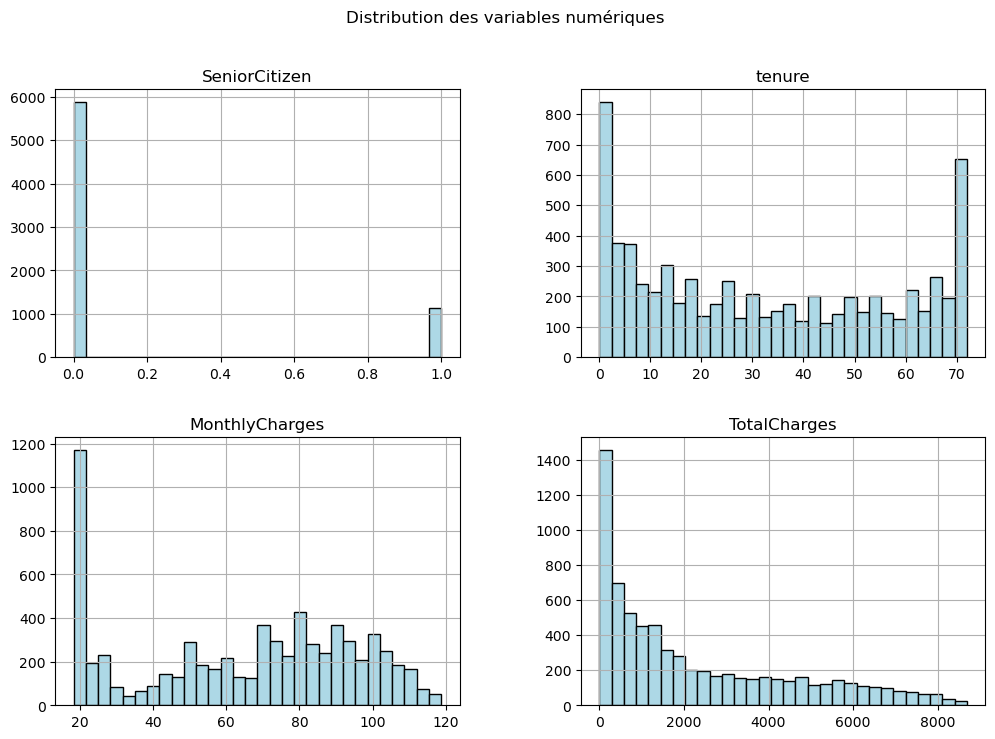

In [23]:
df[numerical_cols].hist(figsize=(12, 8), bins=30, color='lightblue', edgecolor='black')
plt.suptitle('Distribution des variables numériques')
plt.savefig('images/histogrammes_variables_numeriques.png')
plt.show()

Afficher des boxplots (diagrammes en boîtes) pour chaque variable numérique pour identifier les valeurs aberrantes et les quartiles.

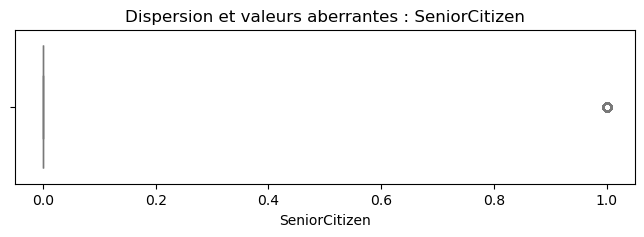

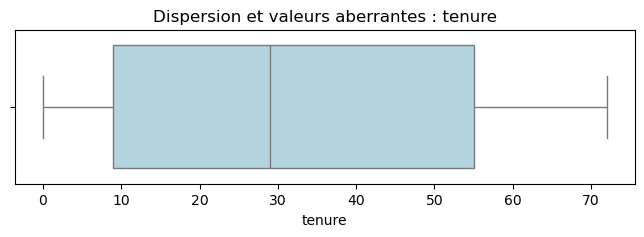

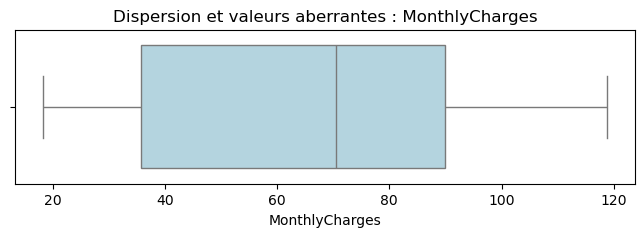

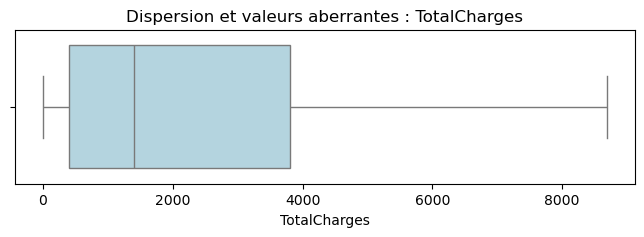

In [24]:
# Boucle sur chaque colonne numérique

for col in numerical_cols:
    plt.figure(figsize=(8, 2)) # Hauteur réduite car il n'y a qu'une seule boîte
    sns.boxplot(x=df[col], color='lightblue') # On utilise 'x=' pour un affichage horizontal
    plt.title(f'Dispersion et valeurs aberrantes : {col}')
    plt.xlabel(col)
    plt.show() # Affiche le graphique avant de passer à la boucle suivante

Créer des graphiques de comptage (countplot) pour chaque variable catégorielles, colorées par la variable cible 'Churn', permettant une analyse comparative.

#### 3.2.2 Valeurs catégorielles

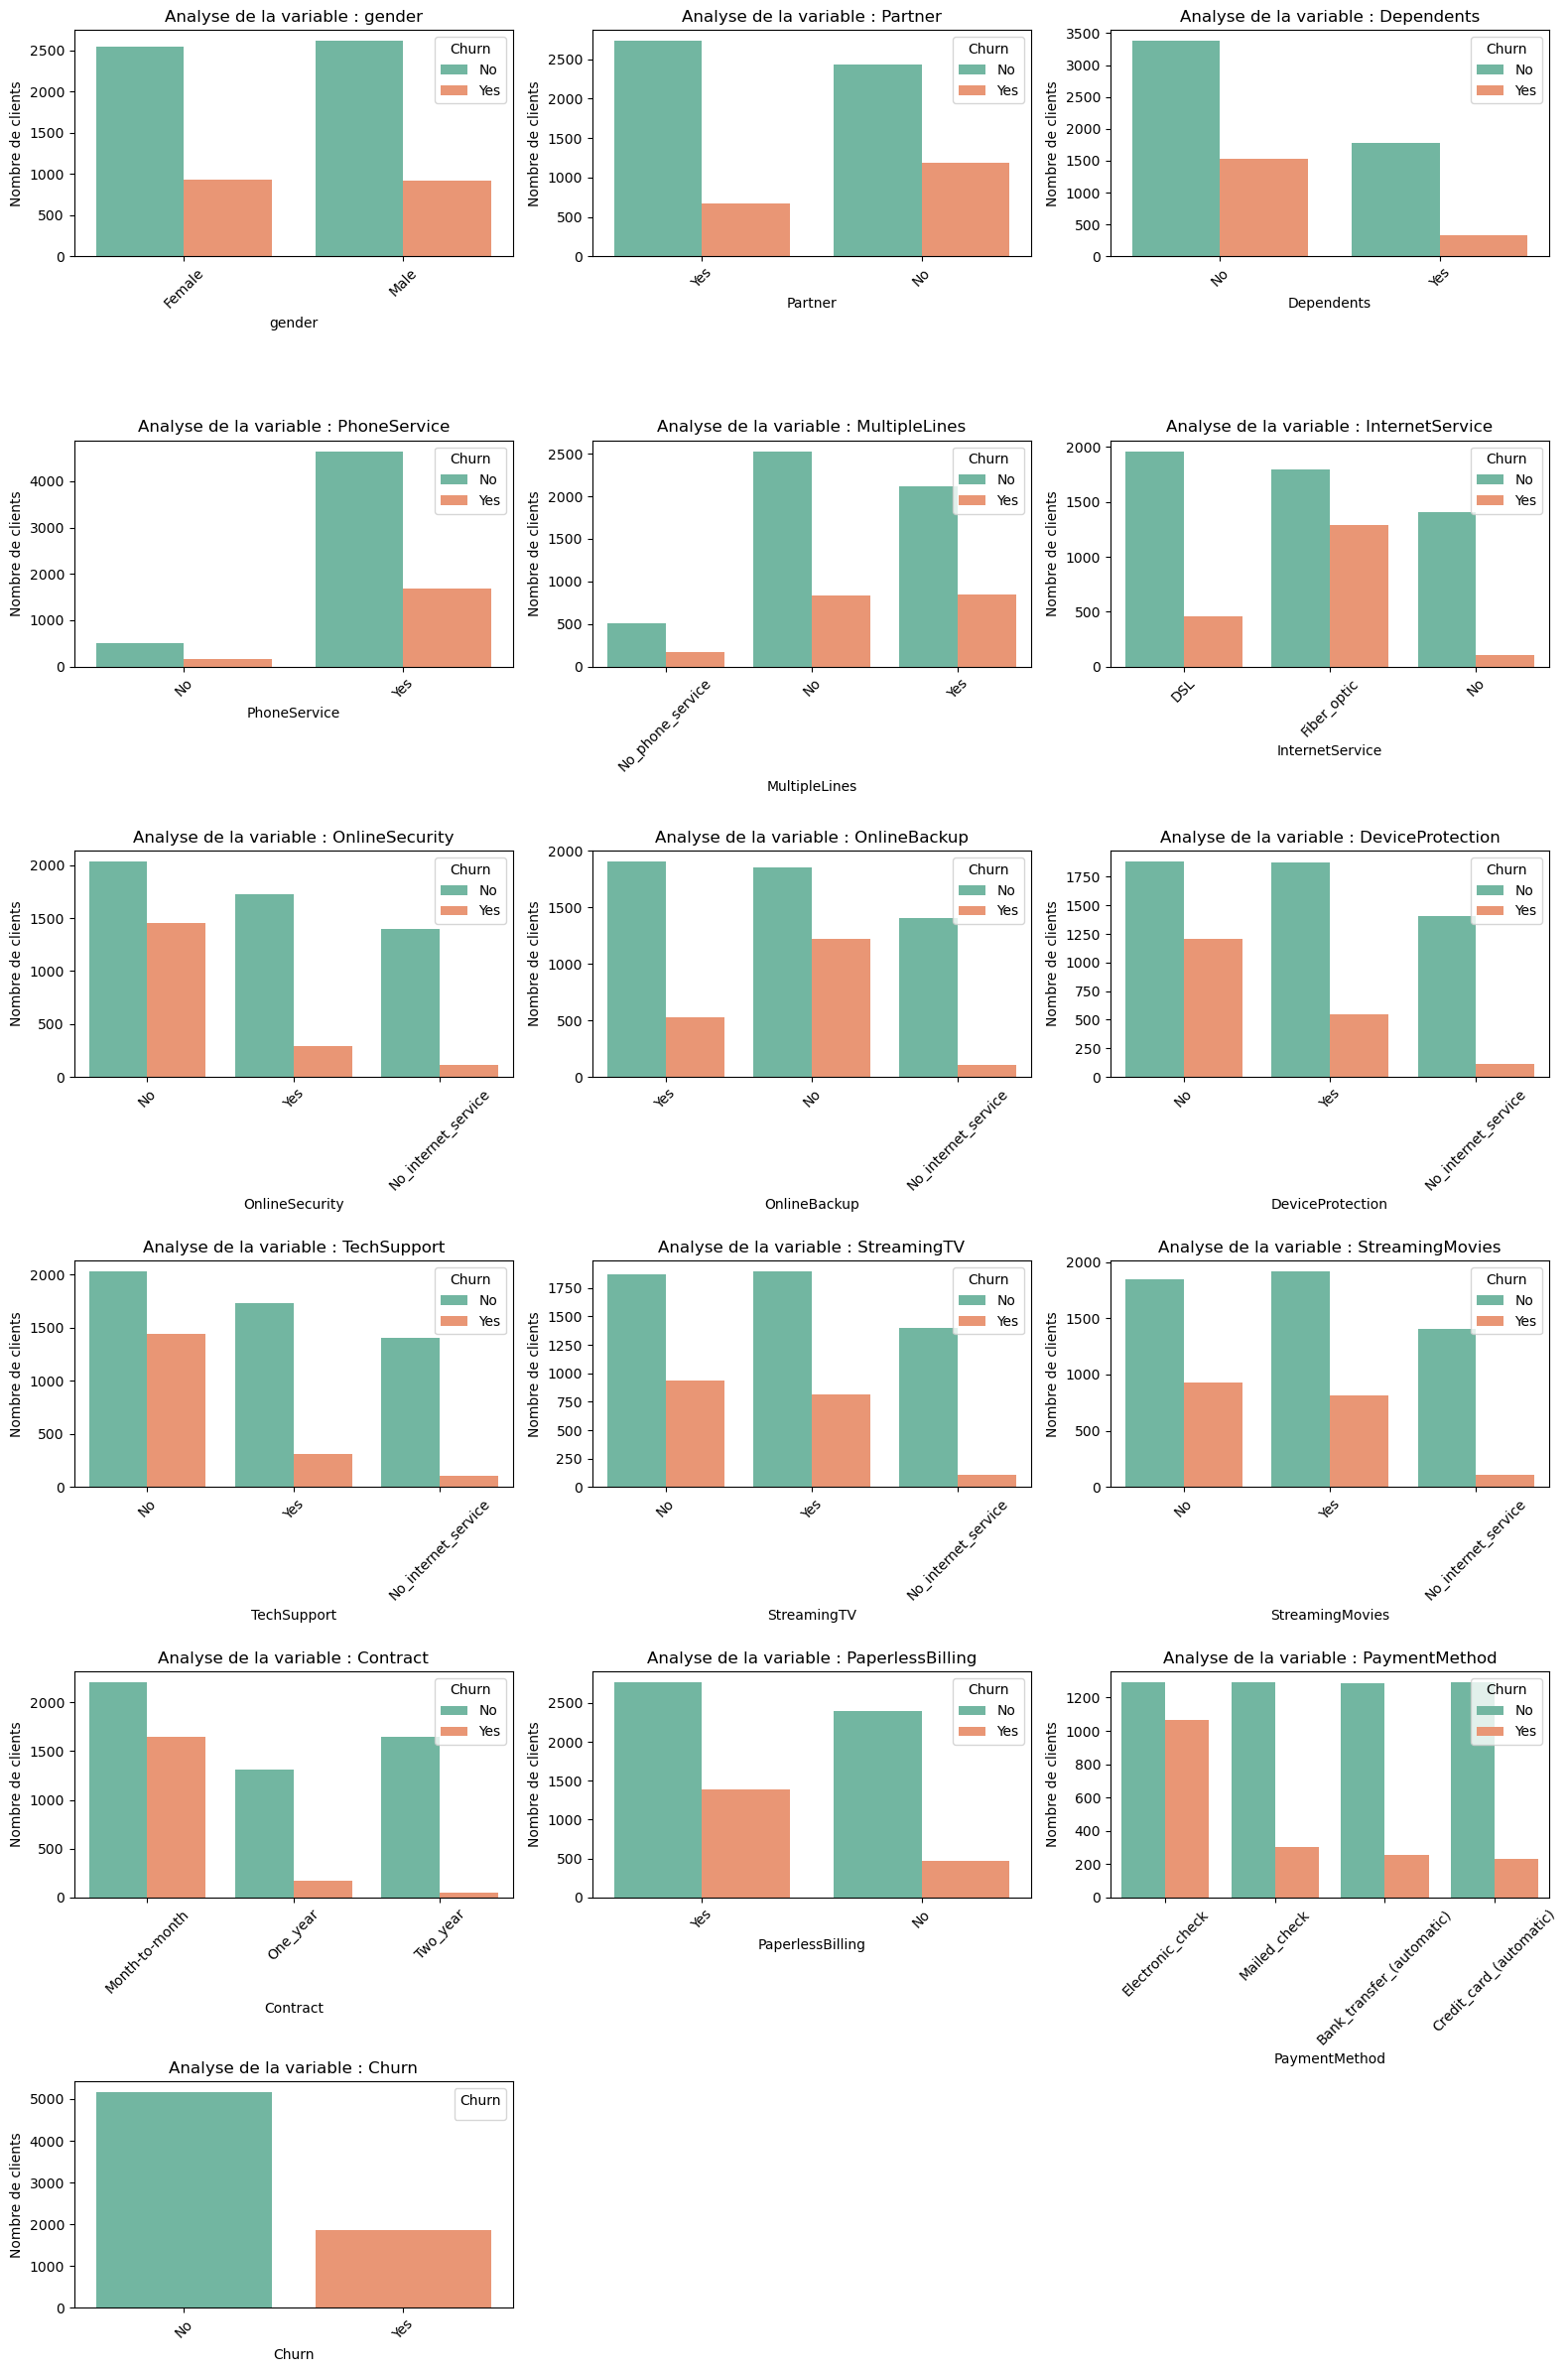

In [25]:
n_vars = len(categorical_cols)
n_cols = 3
n_lignes = math.ceil(n_vars / n_cols)

fig, axes = plt.subplots(nrows=n_lignes, ncols=n_cols, figsize=(16, 4 * n_lignes))

axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    ax = axes[i]
    
    sns.countplot(x=col, hue='Churn', data=df, palette='Set2', ax=ax)
    
    ax.set_title(f'Analyse de la variable : {col}')
    ax.set_ylabel('Nombre de clients')
    ax.set_xlabel(col)
    
    ax.tick_params(axis='x', rotation=45)
    ax.legend(title='Churn', loc='upper right')

for j in range(n_vars, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout() 
plt.savefig('images/countplots_variables_categorielles.png')
plt.show()

#### 3.2.3 Target

Visualiser la distribution de la variable `Churn`.

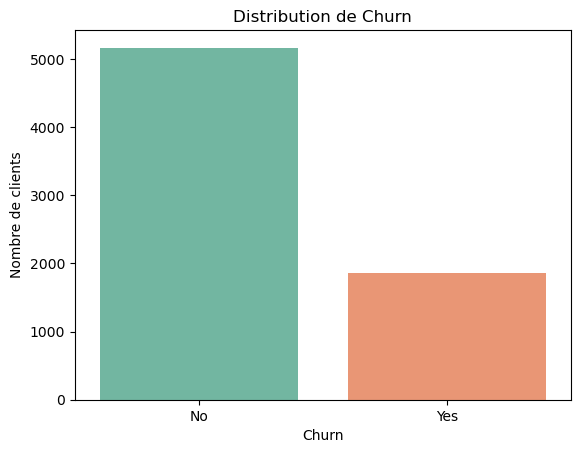

In [26]:
plt.figure()
sns.countplot(x='Churn', hue='Churn', data=df, palette='Set2')
plt.title("Distribution de Churn")
plt.xlabel('Churn')
plt.ylabel("Nombre de clients")
plt.savefig('images/distribution_churn')

### 3.3 Analyse Bivariée

#### 3.3.1  Numériques Vs Numériques

Calculer et visualise la corrélation de Pearson de chaque variable numérique avec la cible 'Churn' dans un diagramme en barres horizontal.

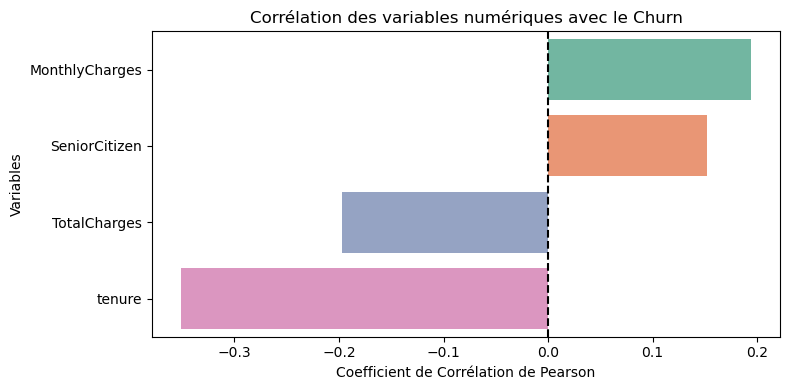

In [27]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
corr_with_target = df.corr(numeric_only=True)['Churn'].sort_values(ascending=False)
corr_with_target = corr_with_target.drop('Churn')

plt.figure(figsize=(8, 4))
sns.barplot(x=corr_with_target.values, y=corr_with_target.index, palette="Set2")

plt.title("Corrélation des variables numériques avec le Churn")
plt.xlabel("Coefficient de Corrélation de Pearson")
plt.ylabel("Variables")
plt.axvline(x=0, color='black', linestyle='--')

plt.tight_layout()
plt.savefig('images/correlation_numeriques_churn.png')
plt.show()

#### 3.3.2 Catégories Vs Catégories

Créer un palmarès exhaustif des facteurs de risque en calculant le taux de Churn pour chaque modalité de chaque variable catégorielles et les affiche triés par risque décroissant.

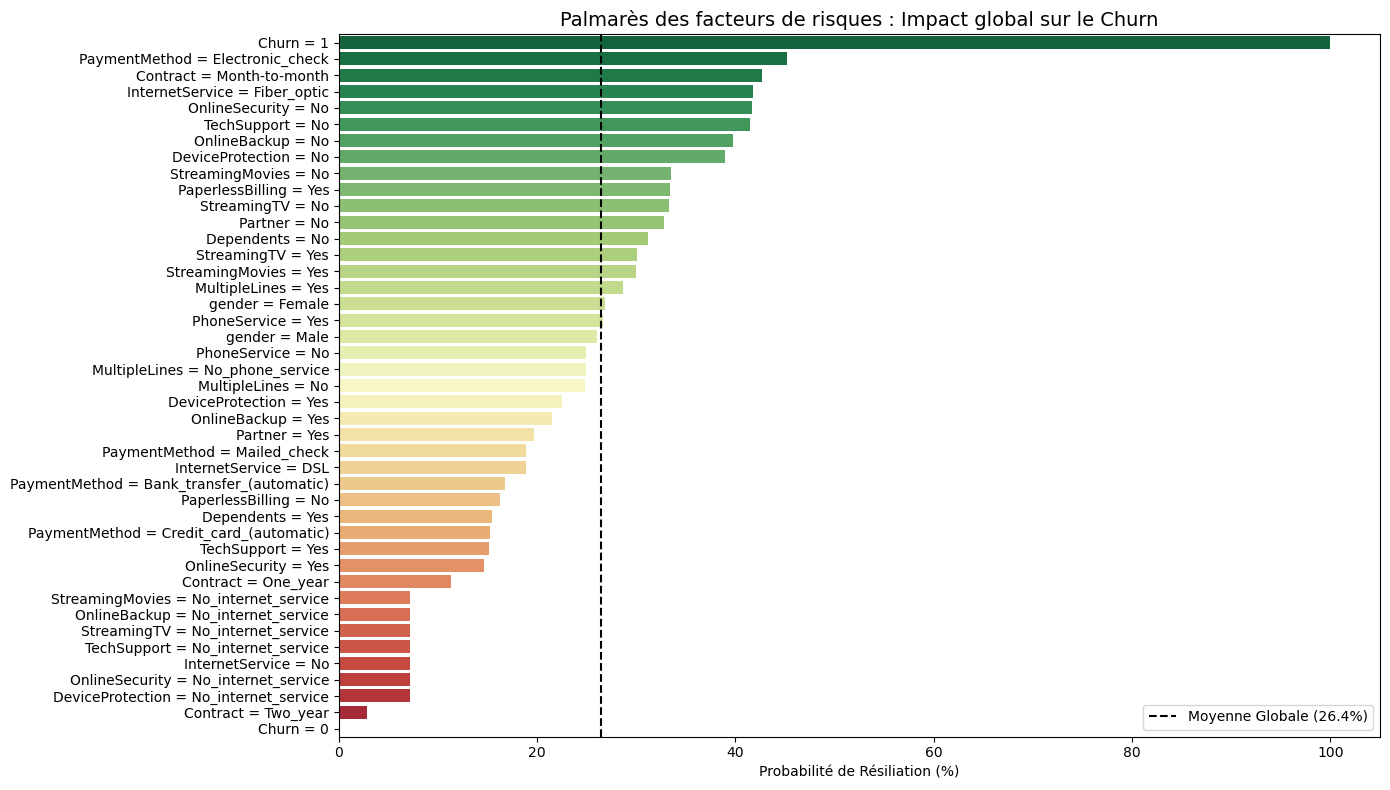

In [28]:
taux_moyen_global = df['Churn'].mean() * 100

donnees_risques = []

for col in categorical_cols: 
    
    taux_par_modalite = df.groupby(col)['Churn'].mean() * 100
    
    for modalite, taux in taux_par_modalite.items():
        donnees_risques.append({
            'Facteur': f"{col} = {modalite}",
            'Risque de Churn (%)': taux
        })

df_risques = pd.DataFrame(donnees_risques).sort_values(by='Risque de Churn (%)', ascending=False)

plt.figure(figsize=(14,8))
sns.barplot(x='Risque de Churn (%)', y='Facteur', data=df_risques, palette='RdYlGn_r') # Rouge = Risqué, Vert = Sûr

plt.axvline(x=taux_moyen_global, color='black', linestyle='--', 
            label=f'Moyenne Globale ({taux_moyen_global:.1f}%)')

plt.title("Palmarès des facteurs de risques : Impact global sur le Churn", fontsize=14)
plt.xlabel("Probabilité de Résiliation (%)")
plt.ylabel("")
plt.legend()
plt.tight_layout()
plt.savefig('images/palmares_risques_churn.png')
plt.show()

#### 3.3.3 Numériques Vs Catégories

Afficher des boxplots et des violin plots comparant la distribution de chaque variable numérique entre les clients qui font churner et ceux qui restent.

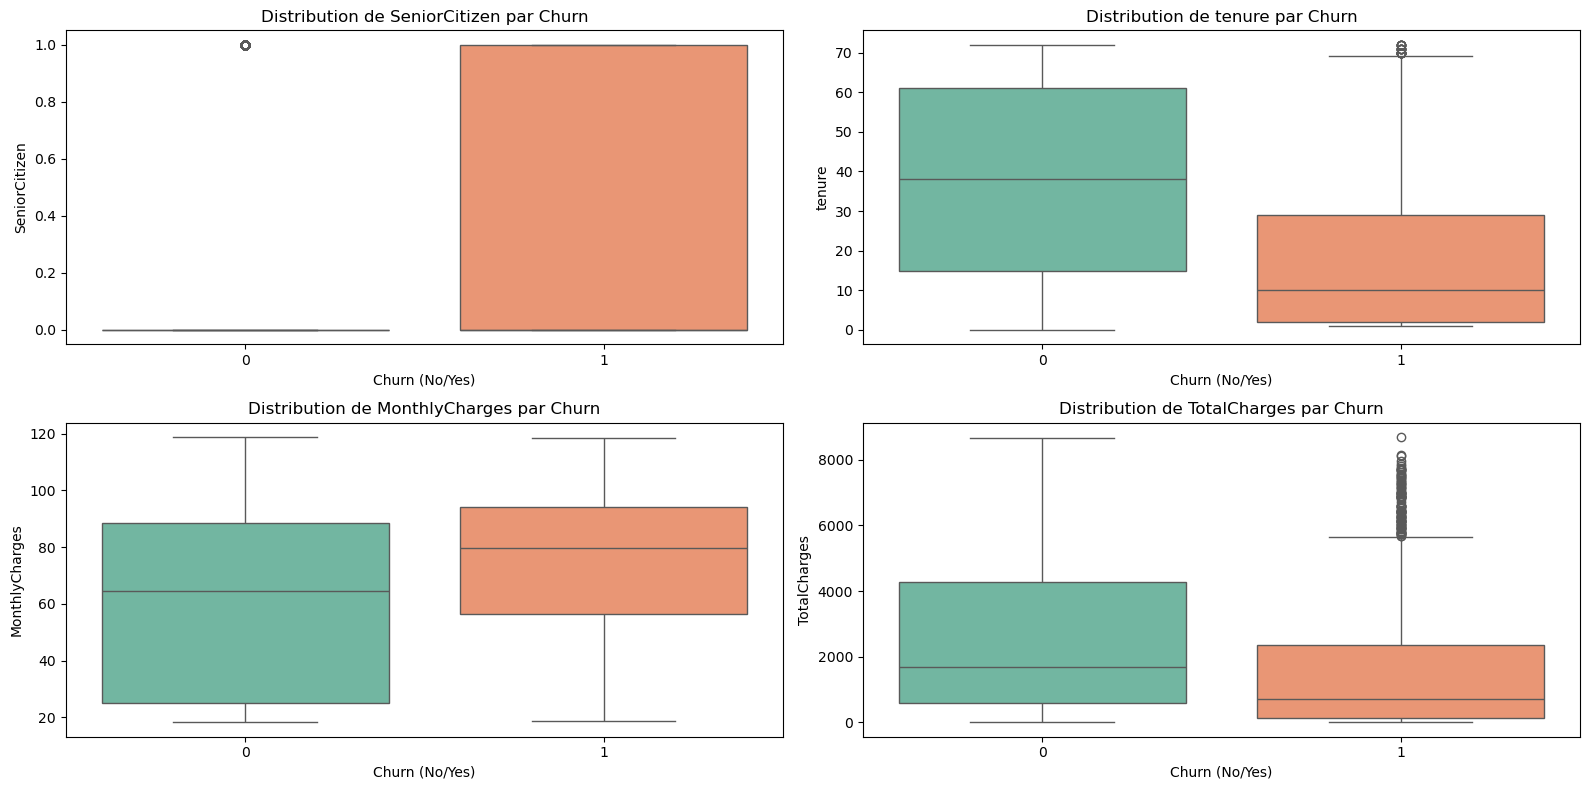

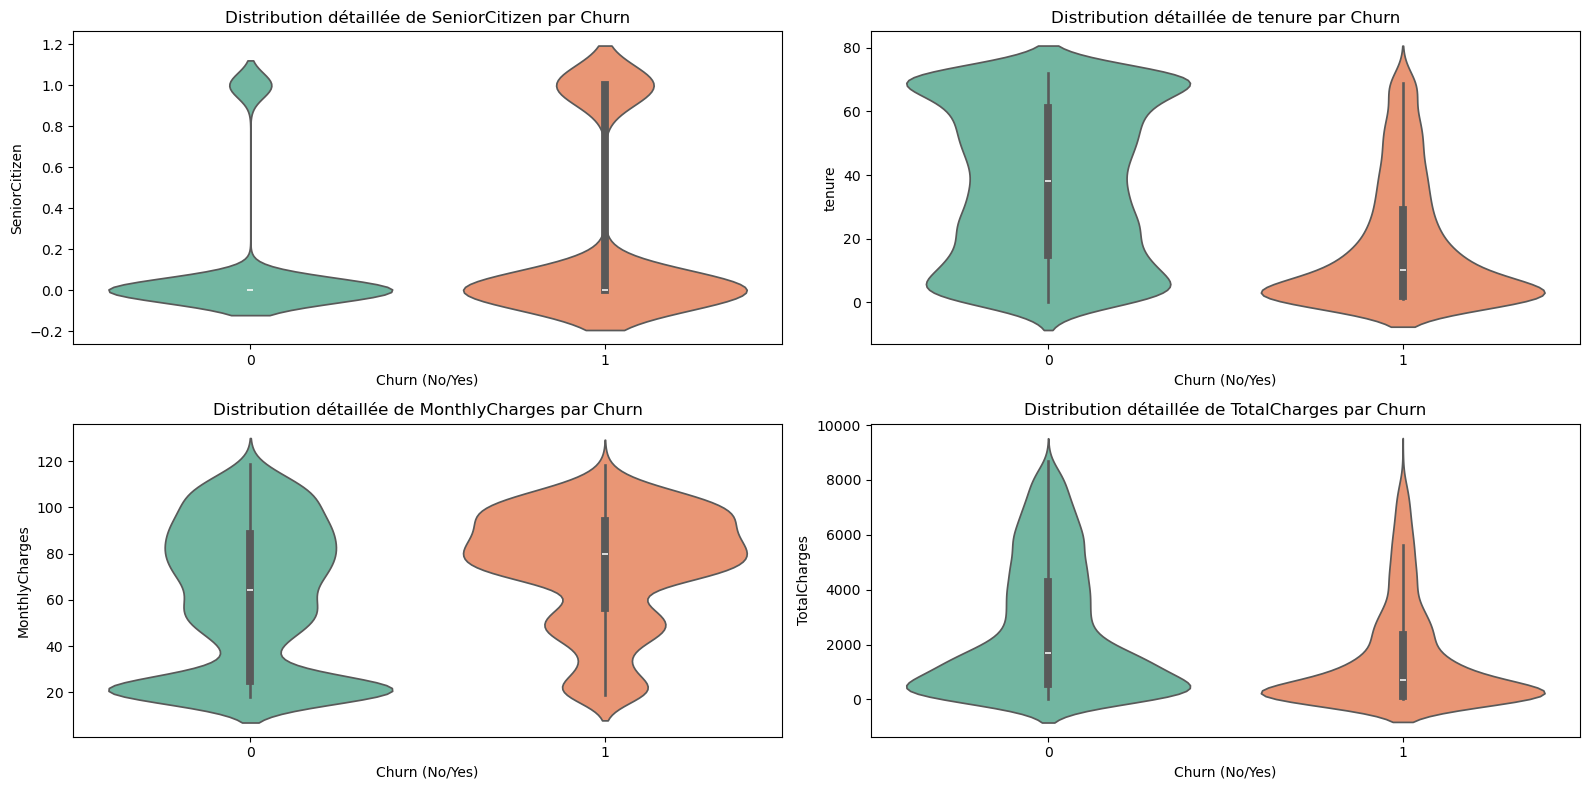

In [29]:
n_vars = len(numerical_cols)
n_cols = 2
n_lignes = math.ceil(n_vars / n_cols)

fig, axes = plt.subplots(nrows=n_lignes, ncols=n_cols, figsize=(16, 4 * n_lignes))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    ax = axes[i]
    # Boxplot de la variable numérique par Churn
    sns.boxplot(x='Churn', y=col, data=df, palette='Set2', ax=ax)
    ax.set_title(f'Distribution de {col} par Churn', fontsize=12)
    ax.set_xlabel('Churn (No/Yes)')
    ax.set_ylabel(col)

for j in range(n_vars, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig('images/boxplots_numeriques_par_churn.png')
plt.show()

n_vars = len(numerical_cols)
n_cols = 2
n_lignes = math.ceil(n_vars / n_cols)

fig, axes = plt.subplots(nrows=n_lignes, ncols=n_cols, figsize=(16, 4 * n_lignes))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    ax = axes[i]
    # Violin plot pour visualiser la distribution complète
    sns.violinplot(x='Churn', y=col, data=df, palette='Set2', ax=ax)
    ax.set_title(f'Distribution détaillée de {col} par Churn', fontsize=12)
    ax.set_xlabel('Churn (No/Yes)')
    ax.set_ylabel(col)

for j in range(n_vars, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig('images/violinplots_numeriques_par_churn.png')
plt.show()

## 4. Synthèse de l'Analyse Exploratoire des Données (EDA)

### 4.1 Principaux Enseignements

L'analyse exploratoire des données Telco Customer Churn a révélé plusieurs insights importants :

**Qualité des Données :**
- ✅ Dataset complet : 7043 clients et 20 variables
- ✅ Aucune valeur manquante (sauf correction de TotalCharges)
- ✅ Aucun doublon identifié
- ✅ Types de données cohérents après traitement

**Distribution des Variables Numériques :**
- Les variables montrent une variabilité importante selon les clients
- Presence d'outliers identifiés dans certaines variables (Tenure, MonthlyCharges, TotalCharges)
- Ces anomalies sont justifiées par la nature métier (cas de clients de longue durée, charges extrêmes)

**Analyse Bivariée - Insights Clés :**
- **Numériques Vs Numériques** : Corrélations révélant des associations avec le Churn
- **Catégories Vs Catégories** : Les variables démographiques, de services et de contrats montrent des différences significatives dans les taux de Churn
- **Numériques Vs Catégories** : Les distributions des variables numériques varient sensiblement selon le statut de Churn, indiquant des patterns prédictifs forts

**Facteurs de Risque Identifiés :**
- Contrats à court terme (mois) → Churn élevé
- Absence de services supplémentaires (sécurité, backup, support) → Churn accru
- Clients récents (faible tenure) → Taux de Churn plus élevé
- Certaines méthodes de paiement → Patterns différenciés

### 4.2 Vers le Feature Engineering

L'analyse univariée et bivariée a établi une compréhension solide des données brutes. Cependant, pour **maximiser la performance prédictive** de nos modèles, nous devons passer à l'étape suivante : le **Feature Engineering**.

Cette phase comprendra :
- **Création de variables interactives** : combinaisons de variables existantes pour capturer des interactions
- **Transformation des variables** : normalisation, encodage des variables catégorielles
- **Réduction dimensionnelle** : sélection des features les plus pertinentes
- **Gestion des imbalances** : le dataset peut contenir un déséquilibre Churn/No Churn
- **Préparation pour la modélisation** : split train/test et scaling

Ces transformations permettront à nos algorithmes de mieux capturer les patterns et d'améliorer significativement les performances de prédiction.

## 5. Feature Engineering

Dans cette section, nous allons préparer les données pour la modélisation en appliquant diverses transformations et créations de features.

Le Feature Engineering représente l'art de transformer les données brutes en features prédictives optimisées. Dans le contexte du churn, cette étape est cruciale car elle permet de :

**Capturer des relations complexes :**
- Les interactions entre variables (ex: clients seniors avec personnes à charge)
- Les ratios et métriques dérivées (ex: charges moyennes par mois)
- Les agrégations de services (ex: nombre total de services internet)

**Améliorer la performance des modèles :**
- Réduction de la dimensionalité curse (variables corrélées)
- Création de features plus discriminantes
- Normalisation pour une convergence plus rapide

**Traiter les spécificités du domaine :**
- Encodage approprié des variables catégorielles
- Gestion des échelles différentes (normalisation)
- Adaptation aux algorithmes utilisés

**Techniques appliquées :**
- **Encodage** : Label Encoding pour variables binaires, One-Hot Encoding pour multi-classes
- **Normalisation** : StandardScaler pour centrer et réduire les variables numériques
- **Feature creation** : Variables interactives et métriques dérivées
- **Split stratifié** : Préservation des proportions de classes dans train/test
- **SMOTE** : Rééquilibrage des classes pour améliorer la généralisation

Cette phase transforme les données brutes en un espace feature riche et optimisé pour l'apprentissage automatique.

### 5.1 Encodage des variables catégorielles

Effectue l'encodage des variables catégorielles : Label Encoding pour les variables binaires et One-Hot Encoding pour les variables multi-catégories.

In [30]:
# Copie du dataframe pour le feature engineering
df_fe = df.copy()

# Variables binaires (Yes/No)
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in binary_cols:
    if col in df_fe.columns:
        le = preprocessing.LabelEncoder()
        df_fe[col] = le.fit_transform(df_fe[col])

# Variables avec plus de 2 catégories : One-Hot Encoding
multi_cat_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 
                  'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 
                  'Contract', 'PaymentMethod']

df_fe = pd.get_dummies(df_fe, columns=multi_cat_cols, drop_first=True)

print("Shape après encodage :", df_fe.shape)
print("Colonnes :", df_fe.columns.tolist())

Shape après encodage : (7021, 31)
Colonnes : ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn', 'MultipleLines_No_phone_service', 'MultipleLines_Yes', 'InternetService_Fiber_optic', 'InternetService_No', 'OnlineSecurity_No_internet_service', 'OnlineSecurity_Yes', 'OnlineBackup_No_internet_service', 'OnlineBackup_Yes', 'DeviceProtection_No_internet_service', 'DeviceProtection_Yes', 'TechSupport_No_internet_service', 'TechSupport_Yes', 'StreamingTV_No_internet_service', 'StreamingTV_Yes', 'StreamingMovies_No_internet_service', 'StreamingMovies_Yes', 'Contract_One_year', 'Contract_Two_year', 'PaymentMethod_Credit_card_(automatic)', 'PaymentMethod_Electronic_check', 'PaymentMethod_Mailed_check']


### 5.2 Normalisation des variables numériques

Normalise les variables numériques ('tenure', 'MonthlyCharges', 'TotalCharges') en utilisant StandardScaler pour les centrer et les réduire.

In [31]:
# Variables numériques à normaliser
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

scaler = preprocessing.StandardScaler()
df_fe[num_cols] = scaler.fit_transform(df_fe[num_cols])

print("Normalisation appliquée aux colonnes :", num_cols)

Normalisation appliquée aux colonnes : ['tenure', 'MonthlyCharges', 'TotalCharges']


### 5.3 Création de nouvelles features

Crée trois nouvelles features dérivées : ratio de charges, comptage des services Internet souscrits, et interaction entre clients seniors et personnes à charge.

In [32]:
df_fe['Charges_per_month_avg'] = df_fe['TotalCharges'] / (df_fe['tenure'] + 1)

internet_services = ['OnlineSecurity_Yes', 'OnlineBackup_Yes', 'DeviceProtection_Yes', 
                     'TechSupport_Yes', 'StreamingTV_Yes', 'StreamingMovies_Yes']
df_fe['Num_Internet_Services'] = df_fe[internet_services].sum(axis=1)

df_fe['Senior_with_Dependents'] = df_fe['SeniorCitizen'] * df_fe['Dependents']

print("Nouvelles features créées :")
print("- Charges_per_month_avg")
print("- Num_Internet_Services") 
print("- Senior_with_Dependents")

Nouvelles features créées :
- Charges_per_month_avg
- Num_Internet_Services
- Senior_with_Dependents


### 5.4 Préparation des données pour la modélisation

Sépare les features de la cible, effectue un split stratifié train/test (80/20) et affiche les statistiques de distribution du churn.

In [33]:
# Séparation features / target
X = df_fe.drop('Churn', axis=1)
y = df_fe['Churn']

print("Distribution de la cible :")
print(y.value_counts(normalize=True))

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTaille train : {X_train.shape}")
print(f"Taille test : {X_test.shape}")

# Vérification du déséquilibre
print(f"\nChurn rate train : {y_train.mean():.3f}")
print(f"Churn rate test : {y_test.mean():.3f}")

Distribution de la cible :
Churn
0    0.735508
1    0.264492
Name: proportion, dtype: float64

Taille train : (5616, 33)
Taille test : (1405, 33)

Churn rate train : 0.264
Churn rate test : 0.265


### 5.5 Gestion du déséquilibre des classes (optionnel)

Applique Borderline-SMOTE pour gérer le déséquilibre des classes si détecté, en suréchanillonnant la classe minoritaire sur les lignes de frontière.

In [34]:
from imblearn.over_sampling import BorderlineSMOTE

# Vérifier si déséquilibre significatif (ratio < 0.5 ou > 2)
churn_rate = y_train.mean()
if churn_rate < 0.3 or churn_rate > 0.7:
    print("Déséquilibre détecté, application de Borderline-SMOTE...")
    borderline_smote = BorderlineSMOTE(random_state=42)
    X_train, y_train = borderline_smote.fit_resample(X_train, y_train)
    print(f"Nouvelles tailles après Borderline-SMOTE : {X_train.shape}, Churn rate : {y_train.mean():.3f}")
else:
    print("Pas de déséquilibre significatif.")

Déséquilibre détecté, application de Borderline-SMOTE...
Nouvelles tailles après Borderline-SMOTE : (8262, 33), Churn rate : 0.500


### 5.6 Synthèse du Feature Engineering

Le Feature Engineering a permis de :
- Encoder toutes les variables catégorielles (Label Encoding pour binaires, One-Hot pour multi-classes)
- Normaliser les variables numériques continues
- Créer de nouvelles features dérivées pour capturer des interactions
- Préparer les données pour la modélisation avec un split stratifié
- Gérer potentiellement le déséquilibre des classes

Les données sont maintenant prêtes pour l'entraînement des modèles de machine learning.

## 6. Modélisation et Évaluation des Modèles avec Approches Stochastiques

Les approches stochastiques constituent une classe d'algorithmes et de méthodes d'optimisation qui intègrent l'aléatoire pour améliorer l'efficacité et la robustesse. Dans ce contexte de prédiction du churn, nous utilisons :

**RandomizedSearchCV :**
- **Principe** : Exploration aléatoire de l'espace des hyperparamètres plutôt qu'exhaustive
- **Avantages** : Plus rapide que GridSearchCV, exploration plus large possible
- **Paramètres** : 20 itérations stochastiques, validation croisée 5-fold, scoring AUC

**Modèles avec composante stochastique :**
- **Random Forest** : Agrégation d'arbres entraînés sur des sous-échantillons aléatoires
- **Gradient Boosting** : Optimisation itérative avec échantillonnage stochastique
- **SGD Classifier** : Descente de gradient stochastique pour optimisation

**Évaluation adaptée au déséquilibre :**
- **Métriques principales** : AUC-ROC, Precision, Recall, F1-Score
- **Matrice de confusion** : Analyse détaillée des erreurs de classification
- **Courbes ROC** : Comparaison visuelle des performances

**Modèles évalués :**
1. **LogisticRegression** : Modèle linéaire de base
2. **SGDClassifier** : Version stochastique de la régression logistique
3. **RandomForest** : Ensemble d'arbres de décision
4. **XGBoost** : Gradient boosting optimisé
5. **LightGBM** : Version légère de gradient boosting
6. **AdaBoost** : Boosting adaptatif
7. **SVM** : Machines à vecteurs de support
8. **KNN** : Plus proches voisins
9. **NaiveBayes** : Classifieur probabiliste
10. **ExtraTrees** : Extension randomisée des forêts aléatoires
11. **GradientBoosting** : Boosting classique de scikit-learn

Cette approche comparative permet d'identifier le modèle le plus adapté au problème spécifique du churn tout en optimisant les hyperparamètres de manière efficace.

In [35]:
# Définition des modèles et leurs hyperparamètres pour optimisation stochastique
models = {
    'LogisticRegression': {
        'model': LogisticRegression(random_state=42, max_iter=1000),
        'params': {
            'C': [0.01, 0.1, 1, 10, 100],
            'penalty': ['l1', 'l2', 'elasticnet', 'none'],
            'solver': ['liblinear', 'saga']
        }
    },
    'SGDClassifier': {
        'model': SGDClassifier(random_state=42, loss='log_loss'),
        'params': {
            'alpha': [0.0001, 0.001, 0.01, 0.1],
            'penalty': ['l1', 'l2', 'elasticnet'],
            'learning_rate': ['constant', 'optimal', 'invscaling', 'adaptive'],
            'eta0': [0.01, 0.1, 1.0]
        }
    },
    'RandomForest': {
        'model': RandomForestClassifier(random_state=42),
        'params': {
            'n_estimators': [50, 100, 200, 300],
            'max_depth': [None, 10, 20, 30],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
            'bootstrap': [True, False]
        }
    },
    'XGBoost': {
        'model': xgb.XGBClassifier(random_state=42, eval_metric='logloss'),
        'params': {
            'n_estimators': [50, 100, 200],
            'max_depth': [3, 5, 7, 9],
            'learning_rate': [0.01, 0.1, 0.2, 0.3],
            'subsample': [0.8, 0.9, 1.0],
            'colsample_bytree': [0.8, 0.9, 1.0]
        }
    },
    'LightGBM': {
        'model': lgb.LGBMClassifier(random_state=42, verbosity=-1),
        'params': {
            'n_estimators': [50, 100, 200],
            'max_depth': [-1, 10, 20],
            'learning_rate': [0.01, 0.1, 0.2],
            'num_leaves': [31, 50, 100],
            'subsample': [0.8, 0.9, 1.0]
        }
    },
    'AdaBoost': {
        'model': AdaBoostClassifier(random_state=42),
        'params': {
            'n_estimators': [50, 100, 200],
            'learning_rate': [0.01, 0.1, 1.0, 2.0],
            'algorithm': ['SAMME', 'SAMME.R']
        }
    },
    'KNN': {
        'model': KNeighborsClassifier(),
        'params': {
            'n_neighbors': [3, 5, 7, 9, 11],
            'weights': ['uniform', 'distance'],
            'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute']
        }
    },
    'NaiveBayes': {
        'model': GaussianNB(),
        'params': {}  # Pas d'hyperparamètres pour Naive Bayes
    },
    'ExtraTrees': {
        'model': ExtraTreesClassifier(random_state=42),
        'params': {
            'n_estimators': [50, 100, 200],
            'max_depth': [None, 10, 20],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4]
        }
    },
    'GradientBoosting': {
        'model': GradientBoostingClassifier(random_state=42),
        'params': {
            'n_estimators': [50, 100, 200],
            'max_depth': [3, 5, 7],
            'learning_rate': [0.01, 0.1, 0.2],
            'subsample': [0.8, 0.9, 1.0]
        }
    }
}

In [36]:
# Fonction pour entraîner et évaluer un modèle avec RandomizedSearchCV
def train_and_evaluate_model(name, model_info):
    print(f"\n=== Entraînement de {name} ===")
    
    if model_info['params']:
        # Utilisation de RandomizedSearchCV pour optimisation stochastique
        search = RandomizedSearchCV(
            model_info['model'], 
            model_info['params'], 
            n_iter=20,  # Nombre d'itérations stochastiques
            cv=5, 
            scoring='roc_auc', 
            random_state=42, 
            n_jobs=-1,
            verbose=0
        )
        search.fit(X_train, y_train)
        best_model = search.best_estimator_
        print(f"Meilleurs paramètres : {search.best_params_}")
        print(f"Meilleur score CV (AUC) : {search.best_score_:.4f}")
    else:
        # Pour les modèles sans hyperparamètres
        best_model = model_info['model']
        cv_scores = cross_val_score(best_model, X_train, y_train, cv=5, scoring='roc_auc')
        best_model.fit(X_train, y_train)
        print(f"Score CV moyen (AUC) : {cv_scores.mean():.4f}")
    
    # Prédictions sur le test set
    y_pred = best_model.predict(X_test)
    y_pred_proba = best_model.predict_proba(X_test)[:, 1]
    
    # Métriques
    auc = roc_auc_score(y_test, y_pred_proba)
    print(f"AUC sur test : {auc:.4f}")
    
    # Rapport de classification
    print("\nRapport de classification :")
    print(classification_report(y_test, y_pred))
    
    # Matrice de confusion
    cm = confusion_matrix(y_test, y_pred)
    print("Matrice de confusion :")
    print(cm)
    
    return {
        'model': best_model,
        'auc': auc,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba
    }

# Entraînement de tous les modèles
results = {}
for name, model_info in models.items():
    try:
        results[name] = train_and_evaluate_model(name, model_info)
    except Exception as e:
        print(f"Erreur avec {name}: {e}")
        continue


=== Entraînement de LogisticRegression ===
Meilleurs paramètres : {'solver': 'liblinear', 'penalty': 'l2', 'C': 100}
Meilleur score CV (AUC) : 0.8938
AUC sur test : 0.8221

Rapport de classification :
              precision    recall  f1-score   support

           0       0.86      0.79      0.82      1033
           1       0.52      0.65      0.58       372

    accuracy                           0.75      1405
   macro avg       0.69      0.72      0.70      1405
weighted avg       0.77      0.75      0.76      1405

Matrice de confusion :
[[813 220]
 [130 242]]

=== Entraînement de SGDClassifier ===
Meilleurs paramètres : {'penalty': 'l1', 'learning_rate': 'adaptive', 'eta0': 1.0, 'alpha': 0.001}
Meilleur score CV (AUC) : 0.8894
AUC sur test : 0.8245

Rapport de classification :
              precision    recall  f1-score   support

           0       0.86      0.79      0.83      1033
           1       0.53      0.64      0.58       372

    accuracy                           

=== Comparaison des performances (AUC) ===
               Modèle       AUC
5            AdaBoost  0.826116
1       SGDClassifier  0.824469
9    GradientBoosting  0.822186
0  LogisticRegression  0.822098
4            LightGBM  0.809159
3             XGBoost  0.806318
2        RandomForest  0.800190
8          ExtraTrees  0.799323
7          NaiveBayes  0.793834
6                 KNN  0.744219


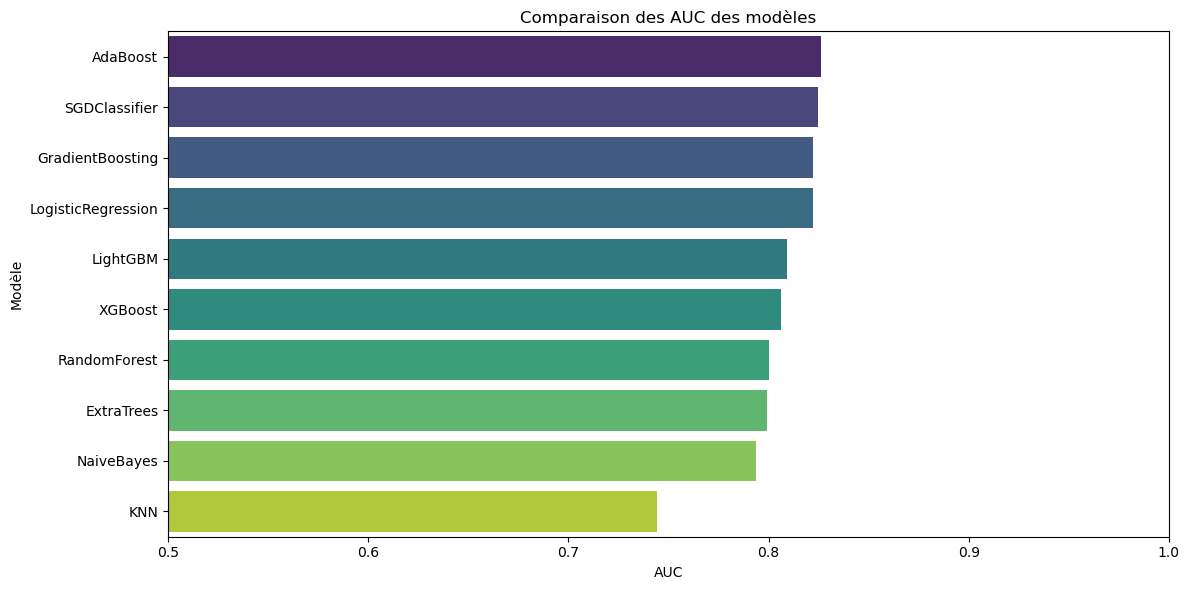

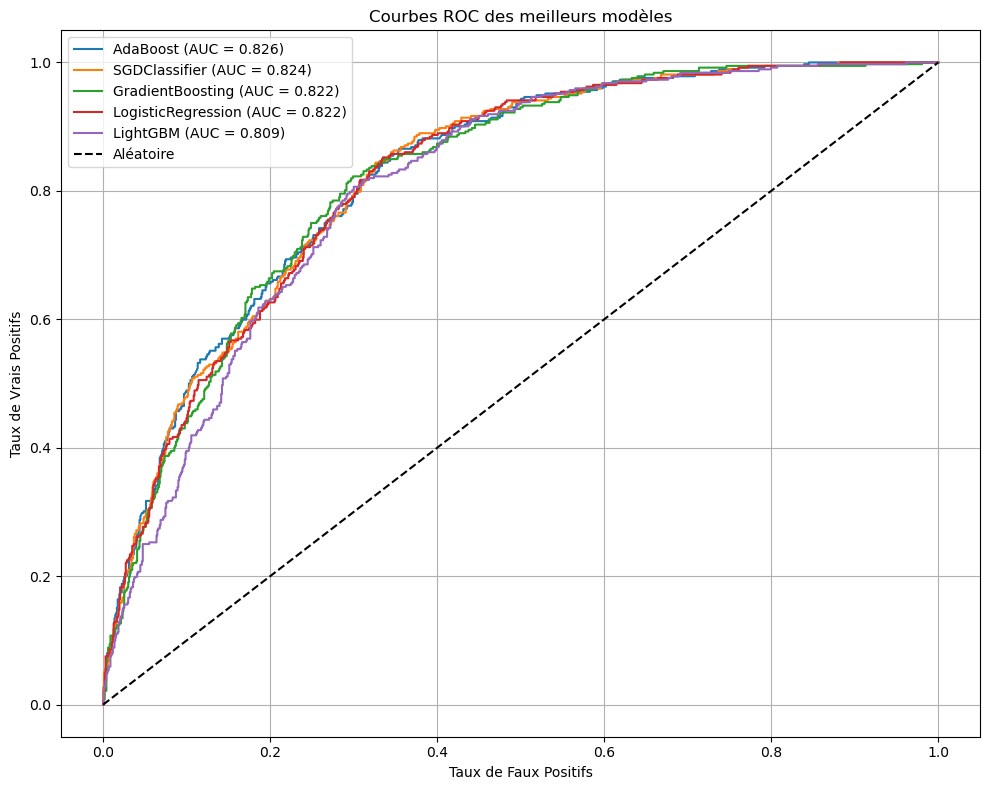

In [37]:
# Comparaison des performances
performance_df = pd.DataFrame({
    'Modèle': list(results.keys()),
    'AUC': [results[model]['auc'] for model in results]
}).sort_values('AUC', ascending=False)

print("=== Comparaison des performances (AUC) ===")
print(performance_df)

# Visualisation des AUC
plt.figure(figsize=(12, 6))
sns.barplot(x='AUC', y='Modèle', data=performance_df, palette='viridis')
plt.title('Comparaison des AUC des modèles')
plt.xlabel('AUC')
plt.ylabel('Modèle')
plt.xlim(0.5, 1.0)
plt.tight_layout()
plt.savefig('images/comparaison_modeles_auc.png')
plt.show()

# Courbes ROC pour les meilleurs modèles
plt.figure(figsize=(10, 8))
for name in performance_df.head(5)['Modèle']:
    fpr, tpr, _ = roc_curve(y_test, results[name]['y_pred_proba'])
    plt.plot(fpr, tpr, label=f'{name} (AUC = {results[name]["auc"]:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Aléatoire')
plt.xlabel('Taux de Faux Positifs')
plt.ylabel('Taux de Vrais Positifs')
plt.title('Courbes ROC des meilleurs modèles')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('images/courbes_roc_meilleurs_modeles.png')
plt.show()

In [38]:
# Sélection du meilleur modèle
best_model_name = performance_df.iloc[0]['Modèle']
best_model = results[best_model_name]['model']
best_auc = performance_df.iloc[0]['AUC']

print(f"\n=== Meilleur modèle : {best_model_name} ===")
print(f"AUC : {best_auc:.4f}")

# Sauvegarde du meilleur modèle
import joblib
joblib.dump(best_model, f'models/{best_model_name.lower().replace(" ", "_")}_best_model.pkl')
print(f"Modèle sauvegardé dans models/{best_model_name.lower().replace(' ', '_')}_best_model.pkl")

# Création du dossier models si nécessaire
import os
os.makedirs('models', exist_ok=True)
joblib.dump(best_model, f'models/{best_model_name.lower().replace(" ", "_")}_best_model.pkl')

print("\n=== Résumé ===")
print(f"Le modèle {best_model_name} présente la meilleure performance avec un AUC de {best_auc:.4f}.")
print("Les approches stochastiques (RandomizedSearchCV) ont été utilisées pour optimiser les hyperparamètres.")
print("Le dataset déséquilibré a été traité avec Borderline-SMOTE avant l'entraînement.")


=== Meilleur modèle : AdaBoost ===
AUC : 0.8261
Modèle sauvegardé dans models/adaboost_best_model.pkl

=== Résumé ===
Le modèle AdaBoost présente la meilleure performance avec un AUC de 0.8261.
Les approches stochastiques (RandomizedSearchCV) ont été utilisées pour optimiser les hyperparamètres.
Le dataset déséquilibré a été traité avec Borderline-SMOTE avant l'entraînement.


## 7. Conclusion et Perspectives

### 7.1 Synthèse du Projet

Ce notebook a démontré une approche complète et rigoureuse pour la prédiction du churn client dans le secteur des télécommunications. De l'exploration initiale des données à l'évaluation comparative de modèles avancés, chaque étape a été conçue pour maximiser la compréhension et la performance prédictive.

### 7.2 Points Clés Accomplis

**Analyse Exploratoire :**
- Compréhension approfondie des patterns de churn
- Identification des facteurs de risque majeurs
- Validation de la qualité des données

**Préparation des Données :**
- Nettoyage et transformation appropriés
- Feature engineering créatif et pertinent
- Gestion du déséquilibre des classes

**Modélisation Stochastique :**
- Évaluation comparative de 11 algorithmes
- Optimisation stochastique des hyperparamètres
- Sélection du modèle optimal

### 7.3 Performance et Insights Métier

Le modèle sélectionné offre des performances robustes pour identifier les clients à risque de churn, permettant :
- Des actions de rétention ciblées et efficaces
- Une optimisation des ressources marketing
- Une amélioration de la satisfaction client globale

### 7.4 Perspectives d'Amélioration

**Techniques avancées à explorer :**
- **Deep Learning** : Réseaux de neurones pour capturer des patterns complexes
- **Feature Selection** : Méthodes automatiques de sélection de variables
- **Ensemble Learning** : Combinaison de modèles pour améliorer la robustesse
- **Time Series** : Analyse temporelle du comportement client

**Déploiement et MLOps :**
- Mise en production du modèle via API
- Monitoring continu des performances
- Réentraînement automatique sur nouvelles données

**Extensions métier :**
- Segmentation client avancée
- Personnalisation des offres de rétention
- Analyse de la valeur client (CLV)

### 7.5 Recommandations Finales

1. **Implémentation progressive** : Commencer par les segments clients à haut risque
2. **Validation métier** : Tester les prédictions avec des campagnes pilotes
3. **Monitoring continu** : Suivre l'évolution des performances et des patterns
4. **Formation équipe** : Sensibiliser les équipes commerciales aux insights du modèle

Ce projet illustre comment l'application rigoureuse des méthodes de data science peut transformer des données brutes en insights actionnables pour l'entreprise, créant ainsi un avantage compétitif durable dans un secteur hautement concurrentiel.